In [1]:
using Lux, DifferentialEquations, SciMLSensitivity, Optimization, OptimizationOptimisers, Statistics,DataFrames,CSV,Plots,Random,ComponentArrays

In [2]:
data = "notebooks/1_data_generation/0_noise/HH_4D_data.csv"

"notebooks/1_data_generation/0_noise/HH_4D_data.csv"

In [3]:
file_path = "c:/Users/nirbh/Neural_Spiking_Dynamics/notebooks/1_data_generation/0_noise/HH_4D_data.csv"
HH_data = CSV.read(file_path, DataFrame)

Row,t,V,m,h,n
,Float64,Float64,Float64,Float64,Float64
1,0.0,-65.0,0.05,0.6,0.32
2,0.0393319,-64.6234,0.0506309,0.599951,0.320004
3,0.09066,-64.1443,0.0518335,0.599797,0.320072
4,0.153942,-63.5703,0.0537937,0.599465,0.32025
5,0.230125,-62.9001,0.056704,0.598862,0.320601
6,0.319102,-62.1402,0.0606977,0.597877,0.321194
7,0.421021,-61.2909,0.0659011,0.596378,0.322113
8,0.535416,-60.3503,0.0724236,0.594218,0.323443
9,0.661746,-59.305,0.0804265,0.591227,0.325282


In [4]:
df_ordered = HH_data[:, [:t, :V, :n, :m, :h]]

Row,t,V,n,m,h
,Float64,Float64,Float64,Float64,Float64
1,0.0,-65.0,0.32,0.05,0.6
2,0.0393319,-64.6234,0.320004,0.0506309,0.599951
3,0.09066,-64.1443,0.320072,0.0518335,0.599797
4,0.153942,-63.5703,0.32025,0.0537937,0.599465
5,0.230125,-62.9001,0.320601,0.056704,0.598862
6,0.319102,-62.1402,0.321194,0.0606977,0.597877
7,0.421021,-61.2909,0.322113,0.0659011,0.596378
8,0.535416,-60.3503,0.323443,0.0724236,0.594218
9,0.661746,-59.305,0.325282,0.0804265,0.591227


In [5]:
t_train =  Float32.(df_ordered.t)
z_train = Float32.(Matrix(df_ordered[:, [:V, :n, :m, :h]])')

4×503 Matrix{Float32}:
 -65.0   -64.6235     -64.1443     -63.5703     …  -73.9282    -73.8157
   0.32    0.320004     0.320072     0.32025         0.602677    0.59661
   0.05    0.0506309    0.0518335    0.0537937       0.017261    0.0174914
   0.6     0.599951     0.599797     0.599465        0.219508    0.22644

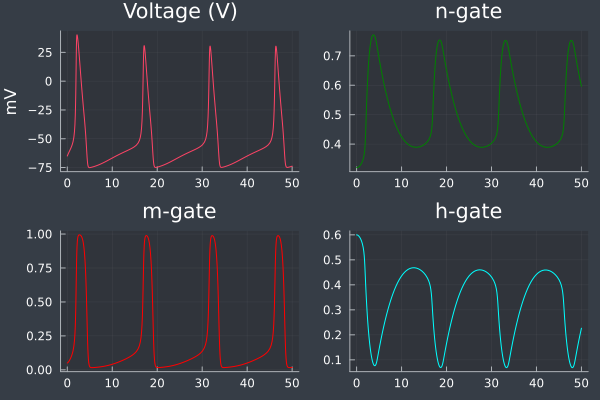

In [6]:
using Plots
theme(:dark)
# Create 4 subplots in a 2x2 grid
p1 = plot(df_ordered.t, df_ordered.V, title="Voltage (V)", ylabel="mV")
p2 = plot(df_ordered.t, df_ordered.n, title="n-gate", color=:green)
p3 = plot(df_ordered.t, df_ordered.m, title="m-gate", color=:red)
p4 = plot(df_ordered.t, df_ordered.h, title="h-gate", color=:cyan)

plot(p1, p2, p3, p4, layout=(2, 2), legend=false)


In [7]:
rng = Random.default_rng()


TaskLocalRNG()

### Scale_Factor

In [8]:
function calculate_scale_factors(z_train,t_train)
          # det the time step (dt)
          dt = diff(t_train) # ( t_i+1 - t_i )

          dz = diff(z_train, dims=2)
          # calculate derivatives ( Finite difference)
          derivatives = dz ./ dt'
          ## result is a 4-element vector: [s_v, s_n, s_m, s_h]
          s_factors = std(derivatives, dims=2)
          


          return s_factors # [s_v, s_n, s_m, s_h]

end

calculate_scale_factors (generic function with 1 method)

In [9]:
# Run this before your optimization loop
scale_factors = calculate_scale_factors(z_train, t_train)

4×1 Matrix{Float32}:
 62.564407
  0.15158027
  0.58253354
  0.13024448

In [10]:
# 3-Layer MLP with LayerNorm
# Input: [v, n, m, h, t] (5 dimensions)
# Output: [dv, dn, dm, dh] (4 dimensions)





nn = Lux.Chain(
    Lux.Dense(5 => 64, Lux.tanh),
    Lux.LayerNorm(64),
    Lux.Dense(64 => 64, Lux.tanh),
    Lux.LayerNorm(64),
    Lux.Dense(64 => 4)
)
rng = Random.default_rng()
ps,st = Lux.setup(rng,nn)
p_initial = ComponentVector(ps) |> Lux.f32




ComponentVector{Float32}(layer_1 = (weight = Float32[-0.25632137 -1.2801452 … -1.1501154 -0.23147; 0.16699913 1.0129552 … 0.27110165 -0.57318336; … ; 0.48952705 -1.1607968 … -0.88204634 -1.1669356; 1.1648178 -1.2504029 … -0.1213336 -0.085806124], bias = Float32[-0.31762207, -0.049450304, 0.08520998, -0.20151015, 0.026010558, 0.17910422, -0.3290535, -0.014329523, 0.066187985, -0.09277175  …  0.010847609, -0.42222077, -0.42847538, 0.21103027, 0.12515903, 0.13108103, -0.0331895, -0.17269175, 0.30985525, 0.17965291]), layer_2 = (bias = Float32[0.0; 0.0; … ; 0.0; 0.0;;], scale = Float32[1.0; 1.0; … ; 1.0; 1.0;;]), layer_3 = (weight = Float32[0.036809172 0.12149853 … 0.043639418 0.16395283; 0.1430863 -0.28403255 … -0.22152492 0.1815416; … ; -0.35496753 0.24219887 … 0.28947142 0.06993777; 0.06863112 -0.039573938 … 0.16204967 -0.23860389], bias = Float32[-0.004813239, 0.07436116, -0.08451514, 0.040804833, 0.11534412, 0.03631781, 0.045448467, -0.08038117, 0.09301932, -0.045698524  …  0.09594305

In [11]:
function hh_equations(u)
    # Extract the 4 state variables from the input matrix
    # Using u[1:1, :] instead of u[1, :] keeps them as 2D arrays (1 x N matrices),
    # which makes the math operations play nicely with Zygote (the automatic differentiator)
    V = u[1:1, :] 
    n = u[2:2, :]
    m = u[3:3, :]
    h = u[4:4, :]
    
    # 1. Physical Parameters 
    I_ext = 10.0f0
    g_Na  = 120.0f0
    g_K   = 36.0f0
    g_L   = 0.3f0
    E_Na  = 50.0f0
    E_K   = -77.0f0
    E_L   = -54.4f0
    C_m   = 1.0f0

    # 2. Compute Ionic Currents using array broadcasting (.)
    I_Na = g_Na .* (m.^3) .* h .* (V .- E_Na)
    I_K  = g_K .* (n.^4) .* (V .- E_K)
    I_L  = g_L .* (V .- E_L)
    
    # 3. Compute True Derivatives
    # Membrane potential (dV/dt)
    dV = (I_ext .- I_Na .- I_K .- I_L) ./ C_m
    
    # Gating variables (dn/dt, dm/dt, dh/dt)
    # Using the alpha and beta rate functions you defined earlier
    dn = α_n.(V) .* (1.0f0 .- n) .- β_n.(V) .* n
    dm = α_m.(V) .* (1.0f0 .- m) .- β_m.(V) .* m
    dh = α_h.(V) .* (1.0f0 .- h) .- β_h.(V) .* h
    
    # 4. Stack the derivatives back into a 4 x N matrix
    return vcat(dV, dn, dm, dh)
end


hh_equations (generic function with 1 method)

### Loss Function ( total_loss = loss_data + Physics_loss)


In [12]:
function pyhysics_loss(nn, state_data, time_data,θ, scale_factors,reconstruct)

          ps_current = reconstruct(θ)
          nn_inputs = vcat(state_data, time_data')

          pred_derivs, _ = nn(nn_inputs, ps_current, st)

          # calculate the HH derivatevies using the equations in section
          true_dervis = hh_equations(state_data)


          #compute scale-aware residual
          residuals = (pred_derivs.-true_dervis)./scale_factors
          
          return mean(residuals.^2)
end

pyhysics_loss (generic function with 1 method)

### The Training Synergy

In [13]:
# Voltage-dependent rate functions for the gating variables
# V is in millivolts (mV). These specific forms are tuned for a resting potential around -65mV.

α_m(V) = 0.1f0 * (V + 40.0f0) / (1.0f0 - exp(-(V + 40.0f0) / 10.0f0))
β_m(V) = 4.0f0 * exp(-(V + 65.0f0) / 18.0f0)

α_h(V) = 0.07f0 * exp(-(V + 65.0f0) / 20.0f0)
β_h(V) = 1.0f0 / (1.0f0 + exp(-(V + 35.0f0) / 10.0f0))

α_n(V) = 0.01f0 * (V + 55.0f0) / (1.0f0 - exp(-(V + 55.0f0) / 10.0f0))
β_n(V) = 0.125f0 * exp(-(V + 65.0f0) / 80.0f0)
# ------------------<>------------<>---------<>----
ps, st = Lux.setup(rng, nn)
p_flat, reconstruct = Optimisers.destructure(ps)

p_initial = Float32.(p_flat)

function neural_dynamics(u, p, t)
    # 1. Reconstruct structured parameters
    ps_structured = reconstruct(p)
    
    # 2. Concatenate u and t to get the 5D input
    # u is [V, n, m, h], t is current time
    raw_input = vcat(u, t) 
    
    # 3. RESHAPE: Turn 1D Vector into 2D Matrix (5x1)
    # This satisfies the LayerNorm dimension check
    input_2d = reshape(raw_input, :, 1)
    
    # 4. Forward Pass
    # Lux models return (output, state); we discard the state here
    dudt_2d, _ = nn(input_2d, ps_structured, st) 
    
    # 5. FLATTEN: Turn 4x1 Matrix back into 1D Vector for the solver
    return vec(dudt_2d)
end
p = Float32[
    10.0,  # External current (μA/cm²) - Try changing this to 2.0 or 20.0!
    120.0, # Max Sodium conductance (mS/cm²)
    36.0,  # Max Potassium conductance (mS/cm²)
    0.3,   # Leak conductance (mS/cm²)
    50.0,  # Sodium reversal potential (mV)
    -77.0, # Potassium reversal potential (mV)
    -54.4, # Leak reversal potential (mV)
    1.0    # Membrane capacitance (μF/cm²)
]

# Initial conditions: [V, m, h,] roughly at resting state
u0 = Float32[-65.0, 0.05, 0.6, 0.32]
tspan = (0.0f0, 50.0f0) # Simulate for 50 illiseconds
node_prob = ODEProblem(neural_dynamics, u0, tspan, p_initial)

ODEProblem with uType Vector{Float32} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 50.0f0)
u0: 4-element Vector{Float32}:
 -65.0
   0.05
   0.6
   0.32

In [14]:
function predict(θ)
          new_prob = remake(node_prob, p=θ)

          return solve(new_prob, Heun(), 
                 saveat=t_train, 
                 reltol=1e-6, abstol=1e-6,
                 sensealg=InterpolatingAdjoint())
end

predict (generic function with 1 method)

### Defining the loss function


In [15]:
function total_loss(θ, _)
    # 1. Trajectory Data Loss
    sol = predict(θ) # Calls solve(remake(node_prob, p=θ), Heun()...)
    if sol.retcode != ReturnCode.Success
        return Inf # Gracefully handle stiff solver failures
    end
    loss_data = mean(abs2, Array(sol) .- z_train)

    # 2. Physics Residual Loss (Pass current θ)
    loss_phys = pyhysics_loss(nn, z_train, t_train, θ, scale_factors, reconstruct)

    # 3. Final Weighted Loss (λ = 1.5)
    λ = 1.5f0
    return loss_data + λ * loss_phys
end

total_loss (generic function with 1 method)

In [16]:
# 1. Create an empty array to track the loss
loss_history = Float32[]
# 2. Define the callback function to save the loss at each step
callback_fn = function (θ, loss_val)
    push!(loss_history, loss_val)
    
    # Optional: Print the loss every 10 iterations so you aren't staring at a blank screen
    if length(loss_history) % 10 == 0
        println("Iteration: $(length(loss_history)) | Loss: $(loss_val)")
    end
    
    return false # False means "do not halt the optimization"
end

#2 (generic function with 1 method)

In [ ]:
# optimization 
optf  = OptimizationFunction(total_loss, Optimization.AutoZygote())
optprob = OptimizationProblem(optf, p_initial)

# 3. Run the optimization, passing our callback_fn
println("Starting Training...")
result = solve(optprob, Adam(0.001), maxiters = 5000, callback = callback_fn)
println("Training Complete!")

Starting Training...
Iteration: 10 | Loss: 583.715
Iteration: 20 | Loss: 565.60754
Iteration: 30 | Loss: 527.47754
Iteration: 40 | Loss: 509.05405
Iteration: 50 | Loss: 496.82355
Iteration: 60 | Loss: 488.41797
Iteration: 70 | Loss: 482.48492
Iteration: 80 | Loss: 478.4512
Iteration: 90 | Loss: 475.6218
Iteration: 100 | Loss: 473.29514
Iteration: 110 | Loss: 472.98474
Iteration: 120 | Loss: 476.17514
Iteration: 130 | Loss: 472.1889
Iteration: 140 | Loss: 469.14987
Iteration: 150 | Loss: 467.3604
Iteration: 160 | Loss: 466.28928
Iteration: 170 | Loss: 464.75775
Iteration: 180 | Loss: 463.669
Iteration: 190 | Loss: 463.34848
Iteration: 200 | Loss: 462.56488
Iteration: 210 | Loss: 461.333
Iteration: 220 | Loss: 461.46805
Iteration: 230 | Loss: 459.7525
Iteration: 240 | Loss: 458.50647
Iteration: 250 | Loss: 458.00604
Iteration: 260 | Loss: 457.89526
Iteration: 270 | Loss: 456.3547
Iteration: 280 | Loss: 460.56708
Iteration: 290 | Loss: 454.60342
Iteration: 300 | Loss: 453.22034
Iteration:

In [ ]:
# 4. Plot the Loss Graph
using Plots
plot(loss_history, 
    title = "PI-NODE Training Loss",
    xlabel = "Epochs (Iterations)", 
    ylabel = "Total Loss", 
    linewidth = 3, 
    color = :neonorange, # Using your preferred neon aesthetics
    grid = true,
    label = "Loss (Data + Physics)"
)